# Google Flu Trends : simulation du mécanisme d'erreur

**Ce notebook est une SIMULATION du mécanisme, pas les vraies données de Google.** Les 45 requêtes retenues n'ont jamais été publiées (Lazer et al., *Science*, 2014, supplément §4). Seuls les ordres de grandeur (50 millions de candidats, 1 152 points d'entraînement) viennent des articles ; tous les autres paramètres sont des choix de modélisation.

**Trois questions, trois expériences**
1. **Sélection** : que se passe-t-il quand on choisit les meilleures corrélations parmi un très grand nombre de candidats ?
2. **Hors saison** : que devient un modèle fondé sur des « détecteurs d'hiver » face à une épidémie non saisonnière (type H1N1, 2009) ?
3. **Dérive** : que devient un modèle figé quand le volume des requêtes change (interface du moteur), et une recalibration avec les données CDC retardées aide-t-elle ?

**Limites** : on ne prouve pas que c'est ce qui s'est passé chez Google, on montre que le mécanisme produit ce type d'erreur.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lfilter
plt.rcParams['figure.dpi'] = 110

def season_shape(t, peak=0):
    return np.maximum(0, np.cos(2 * np.pi * (t - peak) / 52)) ** 2

def simulate(seed=0, n_years=12, n_train_years=6, n_noise=10000, n_winter=1000, n_flu=30,
             drift=1.5, outbreak_amp=1.0, noise_winter=0.25, noise_flu=0.25):
    rng = np.random.default_rng(seed)
    T = n_years * 52
    t = np.arange(T); year = t // 52
    train = t < n_train_years * 52; test = ~train
    amp = rng.uniform(0.6, 1.4, size=n_years)
    flu_true = amp[year] * season_shape(t)
    ob_center = (n_train_years + 2) * 52 + 26          # épidémie estivale dans le test (type H1N1 2009)
    flu_true = flu_true + outbreak_amp * np.exp(-0.5 * ((t - ob_center) / 4) ** 2)
    y = flu_true + rng.normal(0, 0.05, T)
    # (A) bruit AR(1), sans lien avec la grippe (vectorisé : x[i] = 0.9 x[i-1] + e[i])
    noise = lfilter([1.0], [1.0, -0.9], rng.normal(0, 1, (n_noise, T)), axis=1)
    # (B) requêtes "hiver" : saisonnières, sans lien avec la grippe (ex. basket lycée)
    a = rng.uniform(0.6, 1.4, size=(n_winter, n_years))
    winter = a[:, year] * season_shape(t) + rng.normal(0, noise_winter, (n_winter, T))
    # (C) vraies requêtes grippales : suivent la grippe, y compris hors saison
    flu = flu_true + rng.normal(0, noise_flu, (n_flu, T))
    X = np.vstack([noise, winter, flu])
    kinds = np.array(["bruit"] * n_noise + ["hiver"] * n_winter + ["grippe"] * n_flu)
    # dérive : après drift_start, TOUTES les requêtes sont multipliées par `drift`
    # (hypothèse simple : changement de l'interface qui gonfle le volume de recherche)
    drift_start = (n_train_years + 1) * 52
    X_drift = X.copy(); X_drift[:, t >= drift_start] *= drift
    return dict(t=t, y=y, X=X, X_drift=X_drift, kinds=kinds, train=train, test=test,
                flu_true=flu_true, drift_start=drift_start, ob_center=ob_center)

def corr_rows(X, y):
    Xc = X - X.mean(axis=1, keepdims=True); yc = y - y.mean()
    return (Xc @ yc) / (np.linalg.norm(Xc, axis=1) * np.linalg.norm(yc) + 1e-12)

def run(seed=0, k=20, **kw):
    d = simulate(seed=seed, **kw)
    y, X, Xd, kinds, tr, te, t = d["y"], d["X"], d["X_drift"], d["kinds"], d["train"], d["test"], d["t"]
    # ÉTAPE FAUTIVE : sélection des k meilleures corrélations, calculée sur le train uniquement
    r_tr = corr_rows(X[:, tr], y[tr])
    top = np.argsort(-np.abs(r_tr))[:k]
    comp = {kk: int((kinds[top] == kk).sum()) for kk in ["bruit", "hiver", "grippe"]}
    agg = (Xd[top] * np.sign(r_tr[top])[:, None]).mean(axis=0)     # "fraction de requêtes"
    A = np.c_[agg[tr], np.ones(tr.sum())]
    coef, *_ = np.linalg.lstsq(A, y[tr], rcond=None)
    pred = coef[0] * agg + coef[1]                                  # modèle statique type GFT
    lag = np.r_[y[:2], y[:-2]]                                      # référence : valeur d'il y a 2 semaines
    seas = np.r_[y[:52], y[:-52]]
    B = np.c_[agg, lag, seas, np.ones_like(agg)]
    cf, *_ = np.linalg.lstsq(B[tr], y[tr], rcond=None)
    comb = B @ cf
    recal = np.full_like(y, np.nan)                                 # recalibration glissante (104 sem. connues, retard 2 sem.)
    for i in np.where(te)[0]:
        lo, hi = i - 2 - 104, i - 2
        Bw = np.c_[agg[lo:hi], lag[lo:hi], np.ones(hi - lo)]
        cw, *_ = np.linalg.lstsq(Bw, y[lo:hi], rcond=None)
        recal[i] = cw[0] * agg[i] + cw[1] * lag[i] + cw[2]
    mae = lambda p, m: float(np.mean(np.abs(p[m] - y[m])))
    ob = te & (np.abs(t - d["ob_center"]) <= 8)
    post = t >= d["drift_start"]
    peak = post & (y > 0.6)                                         # semaines de pic après la dérive
    res = dict(
        r_train_top=float(np.mean(np.abs(r_tr[top]))),
        r_test_top=float(np.mean([abs(np.corrcoef(X[i, te], y[te])[0, 1]) for i in top])),
        corr_test_agg=float(np.corrcoef(pred[te], y[te])[0, 1]),
        mae_gft=mae(pred, te), mae_lag=mae(lag, te), mae_comb=mae(comb, te), mae_recal=mae(recal, te),
        mae_gft_ob=mae(pred, ob), mae_lag_ob=mae(lag, ob), mae_recal_ob=mae(recal, ob),
        peak_over=float(np.mean(pred[peak] / y[peak])),             # >1 = surestimation aux pics
        comp=comp, max_noise_r=float(np.max(np.abs(r_tr[kinds == "bruit"]))))
    return res, d, pred, lag, recal, top

## 1. Le problème des comparaisons multiples
Séries de **pur bruit** (aucun lien avec la grippe) : plus on en teste, plus la meilleure corrèle avec la cible par hasard. Médiane sur 5 tirages.

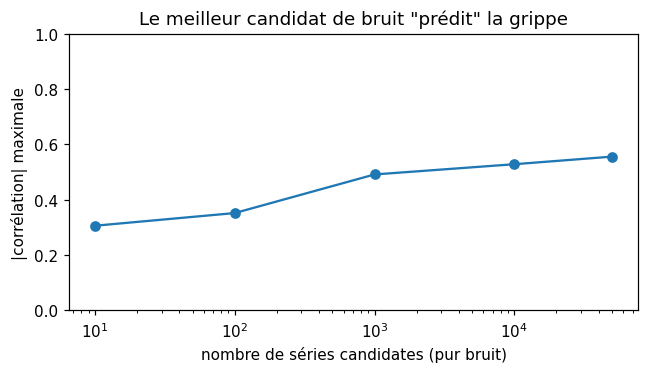

{10: np.float64(0.31), 100: np.float64(0.35), 1000: np.float64(0.49), 10000: np.float64(0.53), 50000: np.float64(0.56)}


In [2]:
rng = np.random.default_rng(1)
T = 312                                    # 6 ans de semaines d'entraînement
y0 = season_shape(np.arange(T)) + rng.normal(0, .05, T)
ns = [10, 100, 1000, 10000, 50000]
best = [np.median([np.abs(corr_rows(lfilter([1], [1, -.9], rng.normal(0, 1, (n, T)), axis=1), y0)).max()
                   for _ in range(5)]) for n in ns]
plt.figure(figsize=(6, 3.5)); plt.semilogx(ns, best, 'o-')
plt.xlabel('nombre de séries candidates (pur bruit)'); plt.ylabel('|corrélation| maximale')
plt.title('Le meilleur candidat de bruit "prédit" la grippe'); plt.ylim(0, 1); plt.tight_layout(); plt.show()
print(dict(zip(ns, np.round(best, 2))))

## 2. Une exécution (graine 0)
`comp` = composition des 20 requêtes retenues. `corr_test_agg` est élevée alors que l'erreur (MAE) est **pire** que la simple valeur d'il y a 2 semaines : **une bonne corrélation n'est pas une bonne prédiction**.

In [3]:
res, d, pred, lag, recal, top = run(seed=0)
for k_, v_ in res.items(): print(f'{k_:14s}', v_ if isinstance(v_, dict) else round(v_, 3))

r_train_top    0.838
r_test_top     0.737
corr_test_agg  0.91
mae_gft        0.131
mae_lag        0.131
mae_comb       0.117
mae_recal      0.108
mae_gft_ob     0.429
mae_lag_ob     0.203
mae_recal_ob   0.291
peak_over      1.03
comp           {'bruit': 0, 'hiver': 16, 'grippe': 4}
max_noise_r    0.549


## 3. L'étape exacte de l'erreur : la sélection par corrélation

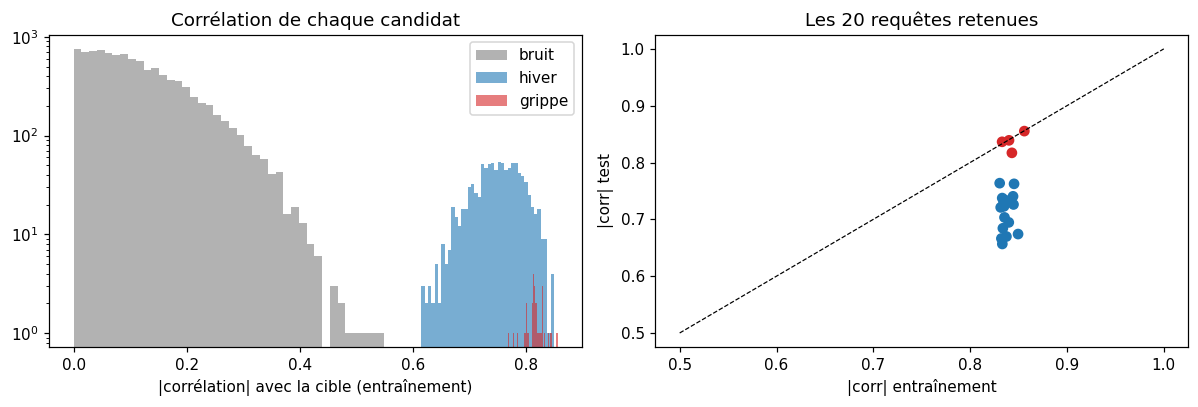

Corrélation max parmi les séries de pur bruit : 0.55
Composition du top 20 : {'bruit': 0, 'hiver': 16, 'grippe': 4}


In [4]:
y, X, kinds, tr, te, t = d['y'], d['X'], d['kinds'], d['train'], d['test'], d['t']
r_tr = corr_rows(X[:, tr], y[tr])
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for kd, c in [('bruit', 'tab:gray'), ('hiver', 'tab:blue'), ('grippe', 'tab:red')]:
    ax[0].hist(np.abs(r_tr[kinds == kd]), bins=40, alpha=.6, label=kd, color=c)
ax[0].set_yscale('log'); ax[0].set_xlabel('|corrélation| avec la cible (entraînement)'); ax[0].legend()
ax[0].set_title('Corrélation de chaque candidat')
r_te = np.array([np.corrcoef(X[i, te], y[te])[0, 1] for i in top])
col = {'bruit': 'tab:gray', 'hiver': 'tab:blue', 'grippe': 'tab:red'}
ax[1].scatter(np.abs(r_tr[top]), np.abs(r_te), c=[col[k] for k in kinds[top]])
ax[1].plot([0.5, 1], [0.5, 1], 'k--', lw=.8)
ax[1].set_xlabel('|corr| entraînement'); ax[1].set_ylabel('|corr| test'); ax[1].set_title('Les 20 requêtes retenues')
plt.tight_layout(); plt.show()
print('Corrélation max parmi les séries de pur bruit :', round(np.abs(r_tr[kinds == 'bruit']).max(), 2))
print('Composition du top 20 :', res['comp'])

**Lecture** : les points sous la diagonale sont des requêtes dont la corrélation *s'effondre* hors échantillon. Les requêtes « hiver » (basket lycée) corrèlent parce qu'elles partagent la saisonnalité, pas parce qu'elles parlent de grippe ; c'est ce que Ginsberg et al. avaient eux-mêmes observé dans leur top 100.

## 4. Prédictions sur les saisons jamais vues

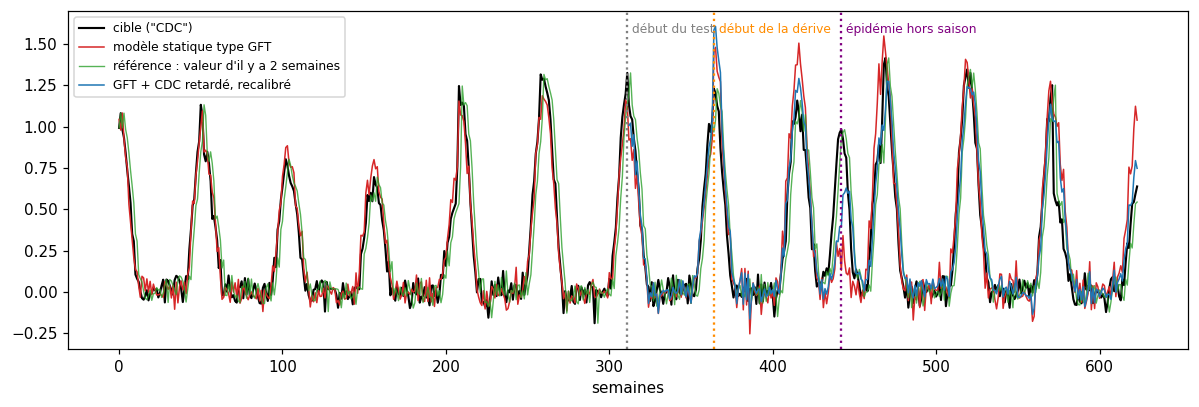

In [5]:
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(t, y, 'k', lw=1.4, label='cible ("CDC")')
ax.plot(t, pred, color='tab:red', lw=1, label='modèle statique type GFT')
ax.plot(t, lag, color='tab:green', lw=.9, alpha=.8, label="référence : valeur d'il y a 2 semaines")
ax.plot(t, recal, color='tab:blue', lw=1, label='GFT + CDC retardé, recalibré')
top_y = ax.get_ylim()[1]
for x_, lab, c in [(t[tr][-1], 'début du test', 'gray'), (d['drift_start'], 'début de la dérive', 'darkorange'),
                   (d['ob_center'], 'épidémie hors saison', 'purple')]:
    ax.axvline(x_, color=c, ls=':'); ax.text(x_ + 3, top_y * .92, lab, fontsize=8, color=c)
ax.set_xlabel('semaines'); ax.legend(loc='upper left', fontsize=8); plt.tight_layout(); plt.show()

## 5. Robustesse : 30 graines (on ne montre pas juste la meilleure)

In [6]:
rs = [run(s)[0] for s in range(30)]
def m(k_): v = np.array([r[k_] for r in rs]); return v.mean(), v.std()
for k_, lab in [('r_train_top', 'corr moyenne entraînement'), ('r_test_top', 'corr moyenne test'),
                ('corr_test_agg', 'corr du modèle agrégé (test)'),
                ('mae_gft', 'MAE test : modèle type GFT'), ('mae_lag', 'MAE test : valeur à -2 sem.'),
                ('mae_recal', 'MAE test : recalibré'),
                ('mae_gft_ob', 'MAE fenêtre épidémie : type GFT'), ('mae_lag_ob', 'MAE fenêtre épidémie : lag 2 sem.')]:
    mu, sd = m(k_); print(f'{lab:38s} {mu:.3f} ± {sd:.3f}')
print()
print('Type GFT moins bon que lag 2 sem. (MAE test) :', sum(r['mae_gft'] > r['mae_lag'] for r in rs), '/ 30')
print('Recalibré meilleur que lag 2 sem.            :', sum(r['mae_recal'] < r['mae_lag'] for r in rs), '/ 30')
print('Vraies requêtes grippales dans le top 20 (moy.):', round(np.mean([r['comp']['grippe'] for r in rs]), 1), '/ 20')
print('Séries de bruit dans le top 20 (moy.)         :', round(np.mean([r['comp']['bruit'] for r in rs]), 1), '/ 20')

corr moyenne entraînement              0.847 ± 0.008
corr moyenne test                      0.726 ± 0.038
corr du modèle agrégé (test)           0.889 ± 0.043
MAE test : modèle type GFT             0.140 ± 0.013
MAE test : valeur à -2 sem.            0.126 ± 0.009
MAE test : recalibré                   0.099 ± 0.013
MAE fenêtre épidémie : type GFT        0.409 ± 0.164
MAE fenêtre épidémie : lag 2 sem.      0.208 ± 0.009

Type GFT moins bon que lag 2 sem. (MAE test) : 25 / 30
Recalibré meilleur que lag 2 sem.            : 30 / 30
Vraies requêtes grippales dans le top 20 (moy.): 4.4 / 20
Séries de bruit dans le top 20 (moy.)         : 0.0 / 20


## 6. Effet de la dérive (volume des requêtes ×1 / ×1,5 / ×2 après la 7e année)

In [7]:
for dr in (1.0, 1.5, 2.0):
    rr = [run(s, drift=dr)[0] for s in range(15)]
    print(f"dérive x{dr}: MAE type GFT = {np.mean([r['mae_gft'] for r in rr]):.3f} | MAE recalibré = {np.mean([r['mae_recal'] for r in rr]):.3f}"
          f" | estimation/réel aux pics = {np.mean([r['peak_over'] for r in rr]):.2f}")

dérive x1.0: MAE type GFT = 0.103 | MAE recalibré = 0.090 | estimation/réel aux pics = 0.78


dérive x1.5: MAE type GFT = 0.142 | MAE recalibré = 0.096 | estimation/réel aux pics = 1.17


dérive x2.0: MAE type GFT = 0.234 | MAE recalibré = 0.101 | estimation/réel aux pics = 1.56


## 7. Ce que cette simulation ne prouve pas
- Elle ne reproduit ni les vraies données ni les vrais termes de Google.
- Le modèle type GFT est battu par la référence simple dans la **majorité** des graines, pas dans toutes : le résultat dépend des paramètres.
- La dérive est une **hypothèse de modélisation** (toutes les requêtes ×k). Lazer et al. la présentent comme une explication *probable*, pas démontrée.
- Le papier de 2009 comportait bien une validation hors échantillon (corrélation 0,97 sur 42 semaines). La critique porte sur la sélection parmi un très grand nombre de candidats et sur l'absence de suivi dans le temps.
- Le bruit des requêtes « hiver » et « grippe » est volontairement identique (0,25) : le dispositif n'avantage pas artificiellement les détecteurs d'hiver.


## Sources
Ginsberg et al., *Nature* 457 (2009) · Lazer, Kennedy, King, Vespignani, *Science* 343 (2014) + supplément · Butler, *Nature* 494 (2013).